
# AI Programming with Python Final Exam

**Name: Fahad Hossain**

**Course Email:**  fahadhossain0503@gmail.com


## End of Assignment

Before submitting:
- Must watch the Exam Instructions Video
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# 0) Starter Code (Run First)

In [82]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

# Question 01: [ Marks 10 ]

Use NumPy arrays from the score and attendance columns. Print both arrays and display:

* Data type
* Number of dimensions
* Shape
* Total number of elements

# Write Answer 01:


In [83]:
print("Student Scores: ", student_scores)
print("Data Type: ", student_scores.dtype)
print("Dimensions: ", student_scores.ndim)
print("Shape: ", student_scores.shape)
print("Size: ", student_scores.size)

print("----------------------------------------")

print("Student Attendance: ", student_attendance)
print("Data Type: ", student_attendance.dtype)
print("Dimensions: ", student_attendance.ndim)
print("Shape: ", student_attendance.shape)
print("Size: ", student_attendance.size)

Student Scores:  [76 90 46 60 48 78 57 43 64 99 53 89 97 48 65 92 41 59 67 86 99 46 83 47
 86 74 53 56 75 89 79 43 41 45 93 81 43 93 68 57 65 83 73 49 75 53 70 87
 54 47]
Data Type:  int64
Dimensions:  1
Shape:  (50,)
Size:  50
----------------------------------------
Student Attendance:  [73 82 99 80 75 77 83 85 84 88 74 60 84 66 68 83 60 67 83 70 76 67 94 94
 92 64 98 87 66 68 67 71 93 92 82 83 96 94 99 81 86 94 60 94 96 73 62 60
 64 85]
Data Type:  int64
Dimensions:  1
Shape:  (50,)
Size:  50


# Question 02: [ Marks 10 ]

## Using NumPy functions on :

* Find the maximum and minimum score
* Calculate the average score
* Calculate the average attendance

Then, extract students who:

* Have a score greater than the average score

Print:

* The filtered score array

## Write Answer 02:


In [84]:
max_score = student_scores.max()
min_score = student_scores.min()
average_score = student_scores.mean()
average_attendance = student_attendance.mean()
# print(max_score, min_score, average_score, average_attendance)

students_greater_then_ave_score = student_scores[student_scores > average_score]

print(students_greater_then_ave_score)

[76 90 78 99 89 97 92 86 99 83 86 74 75 89 79 93 81 93 68 83 73 75 70 87]


# Question 03: [Marks 10]

##
Load the school_data.csv file into a Pandas DataFrame.

* Display the first 3 rows
* Show dataset information using .info()
* Display summary statistics using .describe()

Then filter the dataset to include only:

* student_id, student_age, department, grade

Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.


## Write Answer 03:

In [85]:
df = pd.read_csv('school_data.csv')
# df
print(df.head(3))
print(df.info())
print(df.describe())

filtered_df = df[['student_id', 'student_age', 'department', 'grade']]
filtered_df[(student_ages >= 16) & (student_ages <= 20)].sort_values('student_id').tail(3)

   student_id  student_age  score  attendance department grade
0         201           21     76          73    Physics     B
1         202           18     90          82    Physics     A
2         203           19     46          99    Biology     F
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None
       student_id  student_age      score  attendance
count    50.00000    50.000000  50.000000   50.000000
mean    225.50000    18.280000  67.300000   79.580000
std      14.57738     1.852081  18.248008   12.163998
min     201.00000    15.000000  41.000000   60.

,student_id,student_age,department,grade
45,246,18,Biology,C
47,248,18,Science,A
49,250,17,Economics,F



# Question 04: [ Marks 10 ]

##
Using .loc:

* Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
* Increase the score by 5% for all other departments
* Cap the score at 100 (no score should exceed 100 after the raise)

Then print a DataFrame that includes:

* student_id, department, previous_score, new_score, score_increase


## Write Answer 04:

In [86]:
df['previous_score'] = df['score']

df.loc[(df['department'] == 'Computer Science') | (df['department'] == 'Mathematics'), 'score'] *= 1.1
df.loc[(df['department'] != 'Computer Science') & (df['department'] != 'Mathematics'), 'score'] *= 1.05

df['new_score'] = df['score']
df['score_increase'] = df['new_score'] - df['previous_score']

df.loc[df['new_score'] > 100, 'new_score'] = 100

df[['student_id', 'department', 'previous_score', 'new_score', 'score_increase']]

/tmp/ipykernel_3384/2772055332.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 70.4 108.9  58.3  52.8 108.9  91.3  47.3  74.8  77. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df['department'] == 'Computer Science') | (df['department'] == 'Mathematics'), 'score'] *= 1.1


,student_id,department,previous_score,new_score,score_increase
0,201,Physics,76,79.80,3.80
1,202,Physics,90,94.50,4.50
2,203,Biology,46,48.30,2.30
3,204,Economics,60,63.00,3.00
4,205,Economics,48,50.40,2.40
5,206,Arts,78,81.90,3.90
6,207,Physics,57,59.85,2.85
7,208,Science,43,45.15,2.15
8,209,Computer Science,64,70.40,6.40
9,210,Computer Science,99,100.00,9.90


# Question 05: [ Marks 10 ]

Using Matplotlib, create a bar chart that shows the average score per department.

* X-axis: Department names
* Y-axis: Average score
* Add a title: "Average Score by Department"
* Display the chart

## Answer 05:

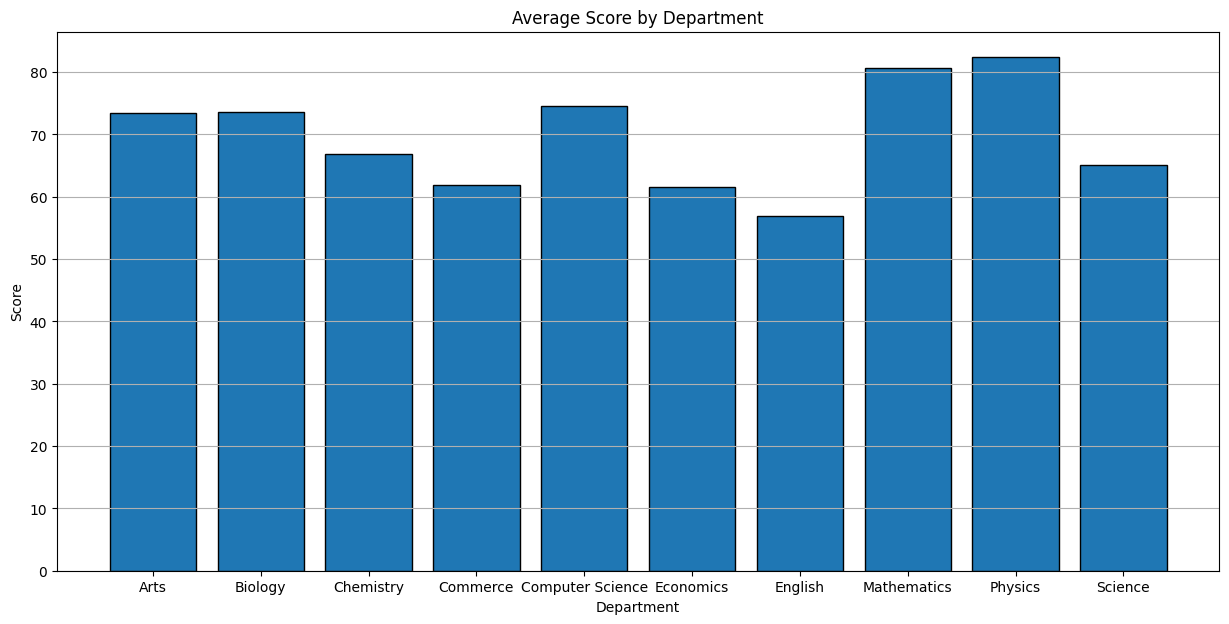

In [87]:
group_by_department = df.groupby('department')['score'].mean()

plt.figure(figsize=(15, 7))
plt.bar(group_by_department.index, group_by_department.values, edgecolor='black')

plt.xlabel("Department")
plt.ylabel("Score")
plt.title("Average Score by Department")
plt.grid(axis='y')
plt.show()

# Question 06: [ Marks 10 ]

Using Matplotlib, create a histogram of the score column.

* Use 10 bins
* Add a title: "Distribution of Student Scores"
* Label X-axis as "Score" and Y-axis as "Number of Students"
* Display the chart

## Answer 06:

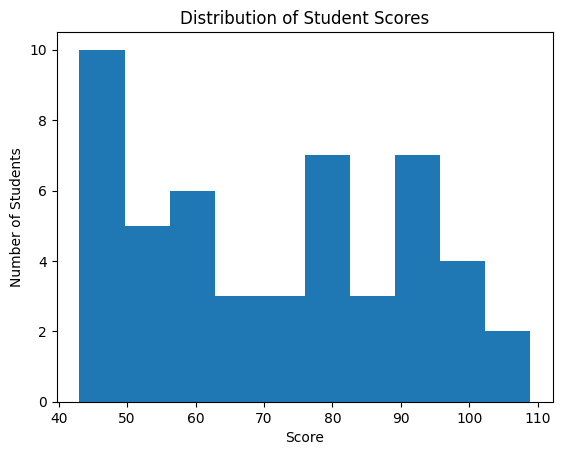

In [88]:
# plt.figure(figsize=(15, 7))
plt.hist(df['score'], bins=10)

plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")
# plt.grid(axis='y')
plt.show()

# Question 07: [ Marks 10 ]

Using Matplotlib, create a scatter plot to visualize the relationship between attendance and score.

* X-axis: Attendance (%)
* Y-axis: Score
* Add a title: "Attendance vs Score"
* Label both axes properly
* Display the chart

## Answer 07:


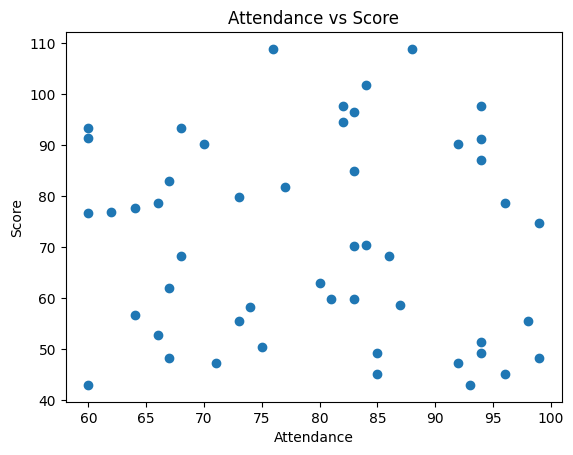

In [89]:
plt.scatter(df['attendance'], df['score'])

plt.xlabel("Attendance")
plt.ylabel("Score")
plt.title("Attendance vs Score")
plt.show()

# Question 08: [ Marks 10 ]

Using Seaborn, create a boxplot / barplot that shows the distribution of score across different grade categories.

* X-axis: Grade
* Y-axis: Score
* Add a title: "Score Distribution by Grade"
* Display the chart

## Answer 08:

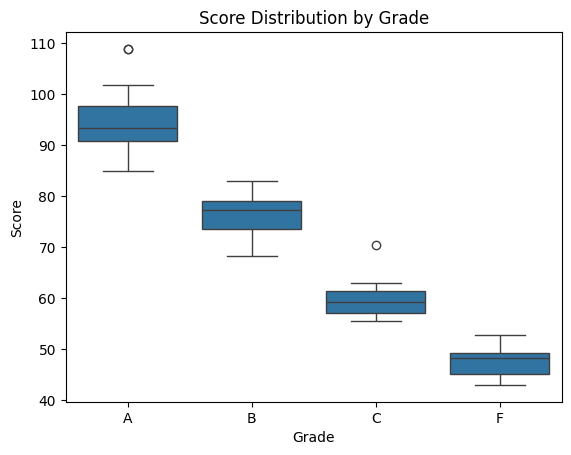

In [90]:
sns.boxplot(data = df, x = 'grade', y = 'score', order=['A', 'B', 'C', 'F'])

plt.xlabel("Grade")
plt.ylabel("Score")
plt.title("Score Distribution by Grade")
plt.show()

# Question 09: [ Marks 10 ]

Using Seaborn, create a countplot showing the number of students in each department.

* Add a title: "Number of Students per Department"
* Display the chart

# Write Answer 09:

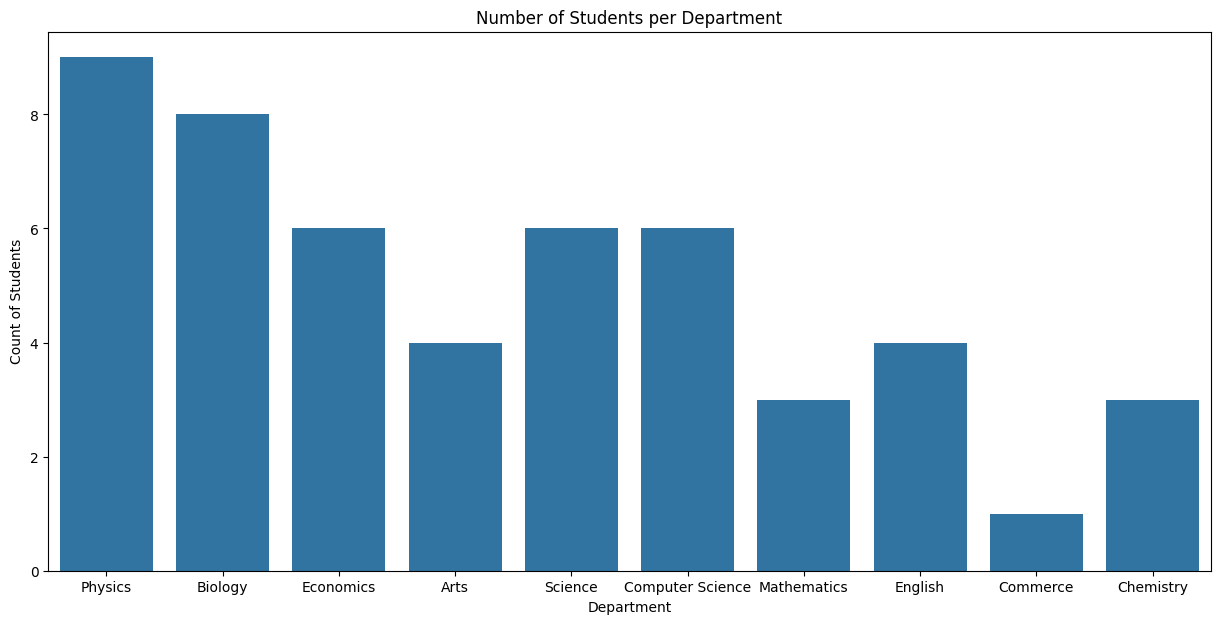

In [95]:
plt.figure(figsize=(15, 7))
sns.countplot(data = df, x = 'department')

plt.xlabel("Department")
plt.ylabel("Count of Students")
plt.title('Number of Students per Department')
plt.show()

# Question 10: [ Marks 10 ]

create a scatter plot showing attendance vs score.

* Color the points by department
* Add a title: "Attendance vs Score by Department"
* Label X-axis as "Attendance (%)" and Y-axis as "Score"
* Display the chart

# Write Answer 10:

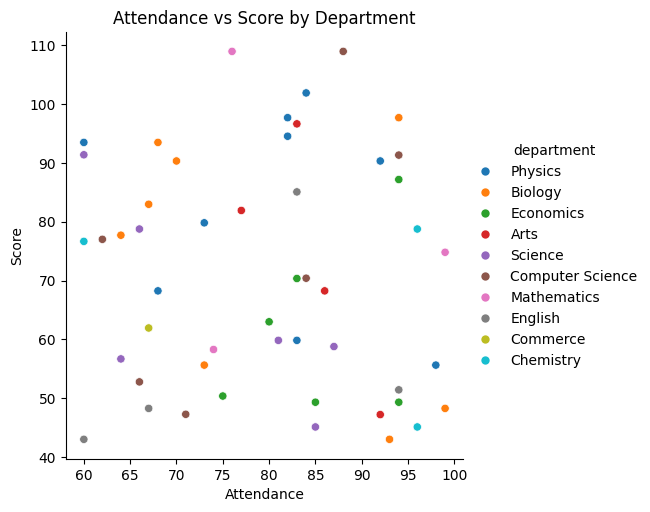

In [92]:
sns.relplot(kind = 'scatter', data = df, x = 'attendance', y = 'score', hue = 'department')

plt.xlabel("Attendance")
plt.ylabel("Score")
plt.title("Attendance vs Score by Department")
plt.show()